# Visualize Optimized SCALP-lite Embedding

Load the optimized graph parameters saved by notebook 01, run the embedding on the selected dataset, plot it, and save the embedded AnnData file for evaluation.


In [1]:
from scalp_lite.notebook_utils import (
    DATASET_REGISTRY,
    dataset_config,
    embed_dataset,
    load_optimized_graph_params,
    load_preprocessed_data,
    make_estimator,
)


selected_dataset = "pancreas"
dataset = dataset_config(selected_dataset)

# These preprocessing settings can be larger than the BO subset once parameters are selected.
preprocess_overrides = {
    "n_top_genes": 2000,
    "max_cells": 6000,
    "min_cell_genes": None,
}

estimator = make_estimator(dataset, n_components=100, random_state=0)
input_path = dataset["input_path"]
output_path = dataset["output_path"]
batch_key = dataset["batch_key"]
label_key = dataset["label_key"]

selected_dataset, input_path, output_path, batch_key, label_key


('pancreas',
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/pancreas_normalized.h5ad'),
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/pancreas_normalized-scalp.h5ad'),
 'study',
 'cell_type')

In [2]:
optimized_params = load_optimized_graph_params(selected_dataset)
graph_params = optimized_params["graph_params"]

optimized_params


{'dataset': 'pancreas',
 'graph_params': {'assignment_quantile': 0.9401229065244358,
  'edge_weighting': 'distance',
  'hubness_correction': 'csls',
  'hubness_k': 20,
  'intra_fraction': 0.649871614435544,
  'metric': 'euclidean',
  'mutual_neighbors': True,
  'n_inter_edges': 4,
  'n_neighbors': 26,
  'neighbor_mode': 'distance',
  'rank_correction': True,
  'symmetrize': True},
 'metadata': {'best_model': 'pca',
  'best_score': 0.934225,
  'gplvm_best_score': 0.9334,
  'pca_best_score': 0.934225,
  'preprocess_overrides': {'max_cells': 2000},
  'random_state': 0}}

In [3]:
adata = load_preprocessed_data(estimator, dataset, **preprocess_overrides)
adata


AnnData object with n_obs × n_vars = 6000 × 1000
    obs: 'batch', 'study', 'cell_type', 'size_factors'
    obsm: 'X_pca'

In [4]:
adata = embed_dataset(adata, estimator, graph_params)
graph_params


{'assignment_quantile': 0.9401229065244358,
 'edge_weighting': 'distance',
 'hubness_correction': 'csls',
 'hubness_k': 20,
 'intra_fraction': 0.649871614435544,
 'metric': 'euclidean',
 'mutual_neighbors': True,
 'n_inter_edges': 4,
 'n_neighbors': 26,
 'neighbor_mode': 'distance',
 'rank_correction': True,
 'symmetrize': True}

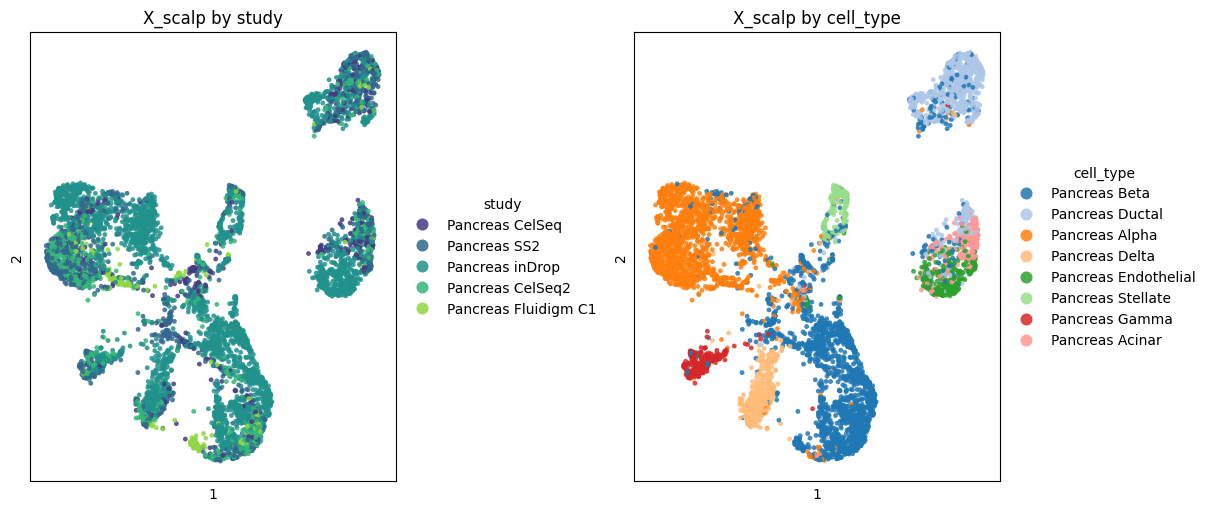

In [5]:
estimator.plot(adata, embedding_key="X_scalp");


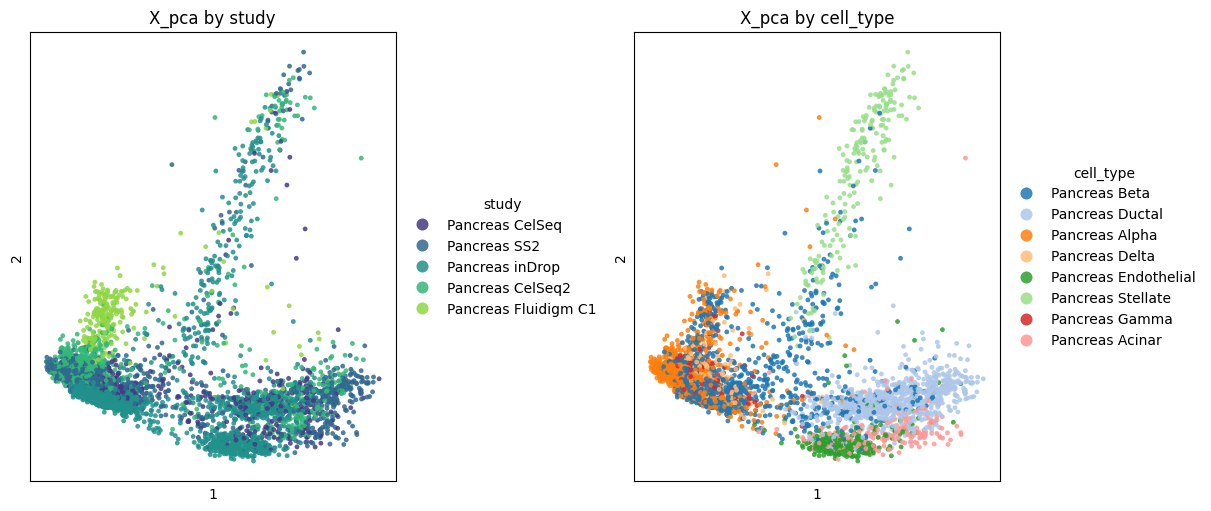

In [6]:
estimator.plot(adata, embedding_key="X_pca");


In [7]:
estimator.save(adata, output_path)
output_path


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/pancreas_normalized-scalp.h5ad')